# Stock-Bond Correlation Regimes Across Crisis Types

**Author**: Deshna Kankaria  
**Date**: April 2026  
**Course**: Quant Mentorship Final Project

## Project Overview

The negative correlation between stocks and bonds served as the foundation of the 60/40 portfolio for over two decades. In 2022 this relationship broke down as both asset classes fell simultaneously during an inflation-driven crisis, producing one of the worst years on record for the 60/40 framework. This project investigates whether the type of macroeconomic shock (growth vs. inflation) explains the breakdown, and whether volatility and yield-curve signals can distinguish the two regimes.

**Research Question**: How has the stock-bond correlation behaved across the four major market stress events from 2005–2026 (2008 financial crisis, 2020 COVID crash, 2022 inflation shock, 2025 tariff crisis), and can GARCH volatility signals and the Treasury yield curve predict correlation regime shifts?

**Dataset**: SPY, TLT, 11 SPDR sector ETFs, VIX (Yahoo Finance), and the 10Y-2Y Treasury yield spread (FRED). Daily data from January 2005 to April 2026.

**Methods**: GARCH(1,1) univariate volatility, DCC-GARCH conditional correlation (implemented from scratch via MLE), rolling correlations and cross-sectional heatmaps for descriptive validation, and a lead-lag analysis between the yield spread and conditional correlation.

**Reference**: Molenaar, R., Senechal, E., Swinkels, L., & Wang, Z. (2024). "Empirical Evidence on the Stock-Bond Correlation." *Financial Analysts Journal*, 80(2).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os

# Core data handling
import pandas as pd
import numpy as np

# Data sources
import yfinance as yf
import pandas_datareader as pdr

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical modeling
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from scipy.optimize import minimize

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Data Collection

This section pulls all data from two sources:

**Yahoo Finance**: SPY (S&P 500 benchmark), TLT (20+ Year Treasury Bond ETF — represents the bond side of the stock-bond correlation), 11 SPDR sector ETFs (XLF, XLE, XLK, XLV, XLY, XLP, XLI, XLB, XLU, XLRE, XLC), and VIX (volatility index).

**FRED**: T10Y2Y (10-Year minus 2-Year Treasury yield spread — a widely-watched recession and rate-regime indicator).

All data is daily, from January 2005 through the present, capturing four major market stress events: the 2008 financial crisis, the 2020 COVID crash, the 2022 inflation shock, and the April 2025 tariff crisis.

In [2]:
# Define the ticker universe
sector_etfs = ['XLF', 'XLE', 'XLK', 'XLV', 'XLY', 'XLP', 'XLI', 'XLB', 'XLU', 'XLRE', 'XLC']
benchmark = ['SPY']
bonds = ['TLT']
vix = ['^VIX']
all_tickers = benchmark + bonds + sector_etfs + vix

# Path to pre-downloaded data
prices_path = 'data/prices_yahoo.csv'

if os.path.exists(prices_path):
    print(f"Loading data from {prices_path}...")
    prices = pd.read_csv(prices_path, index_col=0, parse_dates=True)
else:
    print(f"Local file not found. Downloading {len(all_tickers)} tickers from Yahoo Finance...")
    raw_data = yf.download(
        tickers=all_tickers,
        start='2005-01-01',
        end='2026-04-14',
        auto_adjust=True,
        progress=False
    )
    prices = raw_data['Close'].copy()
    # Reorder columns to ensure consistency
    ordered_cols = benchmark + bonds + sector_etfs + vix
    prices = prices[[col for col in ordered_cols if col in prices.columns]]

print(f"Data ready. Shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")

Loading data from data/prices_yahoo.csv...
Data ready. Shape: (5352, 14)
Date range: 2005-01-03 to 2026-04-13


In [3]:
# Path to pre-downloaded FRED data
yield_path = 'data/yield_spread_fred.csv'

if os.path.exists(yield_path):
    print(f"Loading yield data from {yield_path}...")
    yield_spread = pd.read_csv(yield_path, index_col=0, parse_dates=True)
else:
    print("Local file not found. Downloading T10Y2Y from FRED...")
    yield_spread = pdr.DataReader('T10Y2Y', 'fred', start='2005-01-01', end='2026-04-14')

print(f"Yield data ready. Shape: {yield_spread.shape}")
print(f"NaN count: {yield_spread['T10Y2Y'].isna().sum()}")

Loading yield data from data/yield_spread_fred.csv...
Yield data ready. Shape: (5552, 1)
NaN count: 228


In [4]:
# One-time export of pulled data to CSVs so the repo is self-contained
import os
os.makedirs('data', exist_ok=True)

prices.to_csv('data/prices_yahoo.csv')
yield_spread.to_csv('data/yield_spread_fred.csv')

print("Data saved to data/ folder")
print(f"  prices_yahoo.csv: {prices.shape}")
print(f"  yield_spread_fred.csv: {yield_spread.shape}")

Data saved to data/ folder
  prices_yahoo.csv: (5352, 14)
  yield_spread_fred.csv: (5552, 1)


## 2. Data Cleaning & Alignment

The equity data (Yahoo Finance) and yield curve data (FRED) use different calendars. We align them using an inner join on dates where both sources have valid data, then compute log returns for all price series.

Key cleaning decisions:
- **Inner join** on FRED's non-NaN dates ensures every row has a valid yield spread reading
- **XLRE** (launched 2015) and **XLC** (launched 2018) have NaN values before their launch dates — these are handled explicitly in analyses that require them
- **Log returns** are computed for all price series (equities, TLT, VIX) but NOT for the yield spread, which is used as a level
- **Auto-adjust** was applied during download to account for stock splits and dividends

In [5]:
# Step 1: Drop FRED NaN rows and merge with equity prices
yield_spread_clean = yield_spread.dropna()
master = prices.join(yield_spread_clean, how='inner')

print(f"Master DataFrame shape: {master.shape}")
print(f"Date range: {master.index.min().date()} to {master.index.max().date()}")

# Step 2: Compute log returns for everything except the yield spread
equity_and_vix = master.drop(columns=['T10Y2Y'])
yield_level = master[['T10Y2Y']].copy()

log_returns = np.log(equity_and_vix / equity_and_vix.shift(1))
log_returns = log_returns.dropna(how='all')

# Step 3: Reattach yield spread to log returns
data = log_returns.join(yield_level, how='inner')

print(f"\nFinal analysis DataFrame shape: {data.shape}")
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")
print(f"\nColumns: {list(data.columns)}")
print(f"\nNaN counts:")
print(data.isna().sum())

Master DataFrame shape: (5313, 15)
Date range: 2005-01-03 to 2026-04-13

Final analysis DataFrame shape: (5312, 15)
Date range: 2005-01-04 to 2026-04-13

Columns: ['SPY', 'TLT', 'XLF', 'XLE', 'XLK', 'XLV', 'XLY', 'XLP', 'XLI', 'XLB', 'XLU', 'XLRE', 'XLC', '^VIX', 'T10Y2Y']

NaN counts:
SPY          0
TLT          0
XLF          0
XLE          0
XLK          0
XLV          0
XLY          0
XLP          0
XLI          0
XLB          0
XLU          0
XLRE      2691
XLC       3364
^VIX         0
T10Y2Y       0
dtype: int64


In [6]:
# ADF stationarity test on all series
def run_adf_test(series, name):
    clean_series = series.dropna()
    result = adfuller(clean_series, autolag='AIC')
    return {
        'Series': name,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 6),
        'N obs': len(clean_series),
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

adf_results = [run_adf_test(data[col], col) for col in data.columns]
adf_df = pd.DataFrame(adf_results)

print("ADF Stationarity Test Results")
print("=" * 70)
print(adf_df.to_string(index=False))

ADF Stationarity Test Results
Series  ADF Statistic  p-value  N obs Stationary
   SPY       -13.6321 0.000000   5312        Yes
   TLT       -22.9771 0.000000   5312        Yes
   XLF       -12.2670 0.000000   5312        Yes
   XLE       -14.0363 0.000000   5312        Yes
   XLK       -13.9609 0.000000   5312        Yes
   XLV       -16.7466 0.000000   5312        Yes
   XLY       -13.8808 0.000000   5312        Yes
   XLP       -14.4681 0.000000   5312        Yes
   XLI       -13.6567 0.000000   5312        Yes
   XLB       -13.7709 0.000000   5312        Yes
   XLU       -15.0282 0.000000   5312        Yes
  XLRE       -13.2594 0.000000   2621        Yes
   XLC       -14.3845 0.000000   1948        Yes
  ^VIX       -22.8126 0.000000   5312        Yes
T10Y2Y        -1.5302 0.518507   5312         No


Note: T10Y2Y is non-stationary (p=0.52), a well-documented feature of yield spreads. We use it as a regime indicator, not a model input.

In [7]:
# Identify the most extreme return days for SPY
print("5 worst SPY days:")
print(log_returns['SPY'].nsmallest(5))
print("\n5 best SPY days:")
print(log_returns['SPY'].nlargest(5))

5 worst SPY days:
2020-03-16   -0.115887
2008-10-15   -0.103637
2020-03-12   -0.100569
2008-12-01   -0.092749
2008-09-29   -0.081602
Name: SPY, dtype: float64

5 best SPY days:
2008-10-14    0.120666
2008-10-28    0.110517
2025-04-09    0.099863
2020-03-24    0.086731
2020-03-13    0.082028
Name: SPY, dtype: float64


## 3. Exploratory Data Analysis

This section explores the data visually and statistically, building toward the core observations that motivate the modeling in later sections. Each visualization is tied to a specific observation about volatility regimes, correlation dynamics, or the stock-bond relationship.

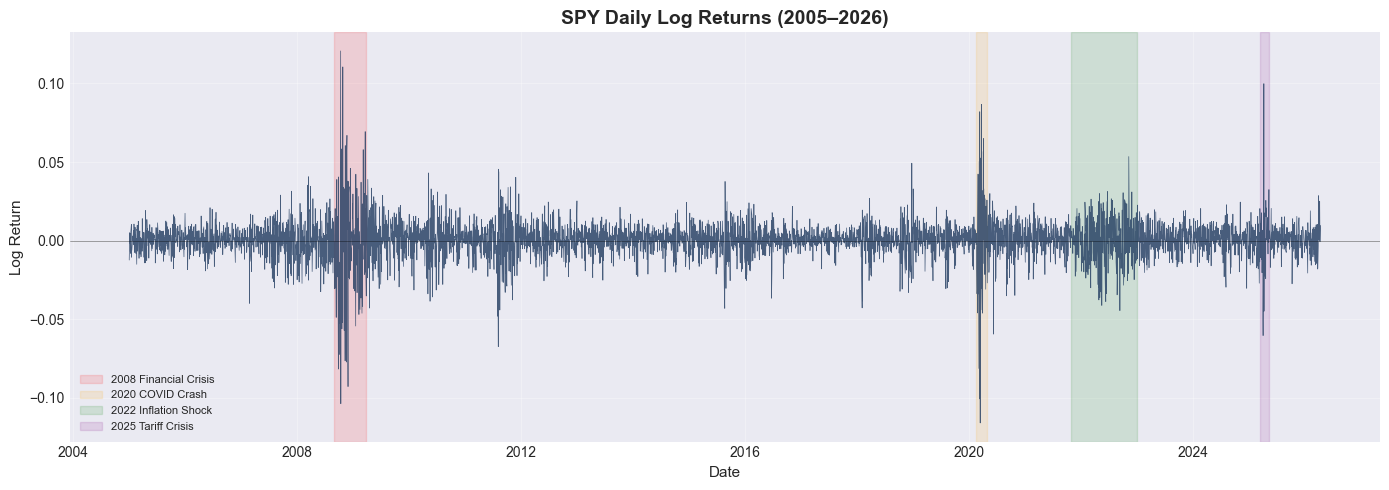

In [8]:
# Chart 1: SPY daily log returns with crisis periods highlighted
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(data.index, data['SPY'], color='#1f3a5f', linewidth=0.5, alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)

# Highlight the four crisis periods central to this study
ax.axvspan('2008-09-01', '2009-03-31', alpha=0.12, color='red', label='2008 Financial Crisis')
ax.axvspan('2020-02-20', '2020-04-30', alpha=0.12, color='orange', label='2020 COVID Crash')
ax.axvspan('2021-11-01', '2022-12-31', alpha=0.12, color='green', label='2022 Inflation Shock')
ax.axvspan('2025-03-15', '2025-05-15', alpha=0.12, color='purple', label='2025 Tariff Crisis')

ax.set_title('SPY Daily Log Returns (2005–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Log Return', fontsize=11)
ax.legend(loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Beyond raw returns, rolling realized volatility makes the clustering pattern more explicit. Periods of elevated volatility persist for weeks rather than resolving overnight, which motivates the GARCH modeling approach applied later.

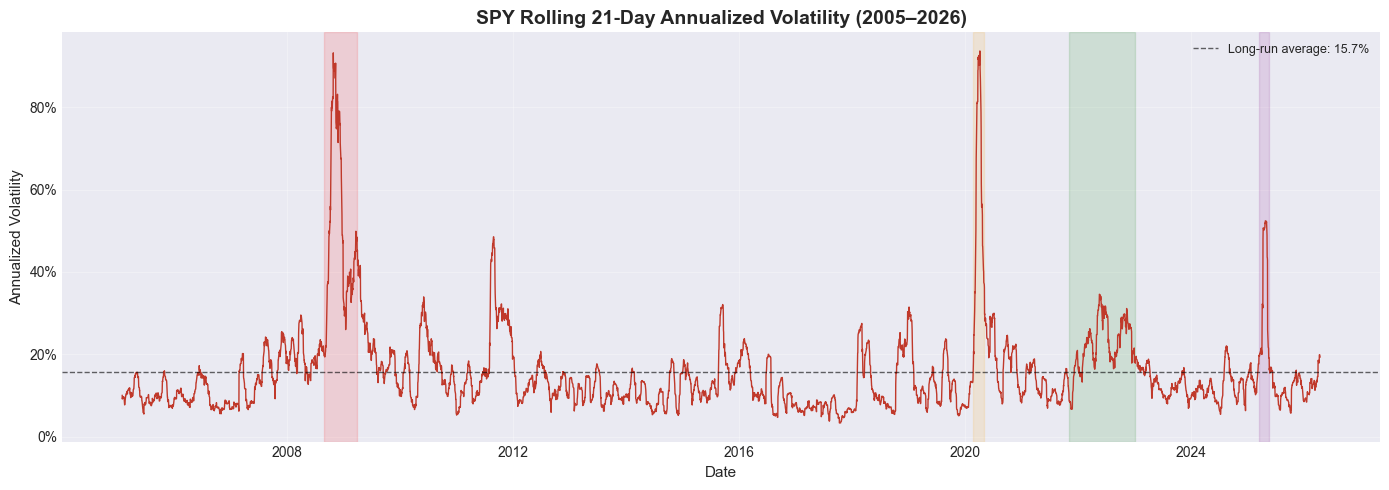

Long-run average volatility: 15.69%
Maximum volatility: 93.67% on 2020-04-06

Observation: Volatility spikes sharply during crises and decays slowly afterward.
The 2008 and 2020 crises produced the highest peaks (~80-90% annualized),
while 2022 shows a different pattern: sustained moderate elevation rather
than a single spike. This difference in volatility signature may relate to
the different nature of the crisis (inflation vs. growth shock).


In [9]:
# Chart 2: Rolling 21-day annualized volatility for SPY
rolling_vol = data['SPY'].rolling(window=21).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_vol.index, rolling_vol, color='#c0392b', linewidth=1)
ax.axvspan('2008-09-01', '2009-03-31', alpha=0.12, color='red')
ax.axvspan('2020-02-20', '2020-04-30', alpha=0.12, color='orange')
ax.axvspan('2021-11-01', '2022-12-31', alpha=0.12, color='green')
ax.axvspan('2025-03-15', '2025-05-15', alpha=0.12, color='purple')

long_run_avg = rolling_vol.mean()
ax.axhline(y=long_run_avg, color='black', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Long-run average: {long_run_avg:.1%}')

ax.set_title('SPY Rolling 21-Day Annualized Volatility (2005–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Annualized Volatility', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Long-run average volatility: {long_run_avg:.2%}")
print(f"Maximum volatility: {rolling_vol.max():.2%} on {rolling_vol.idxmax().date()}")
print(f"\nObservation: Volatility spikes sharply during crises and decays slowly afterward.")
print("The 2008 and 2020 crises produced the highest peaks (~80-90% annualized),")
print("while 2022 shows a different pattern: sustained moderate elevation rather")
print("than a single spike. This difference in volatility signature may relate to")
print("the different nature of the crisis (inflation vs. growth shock).")

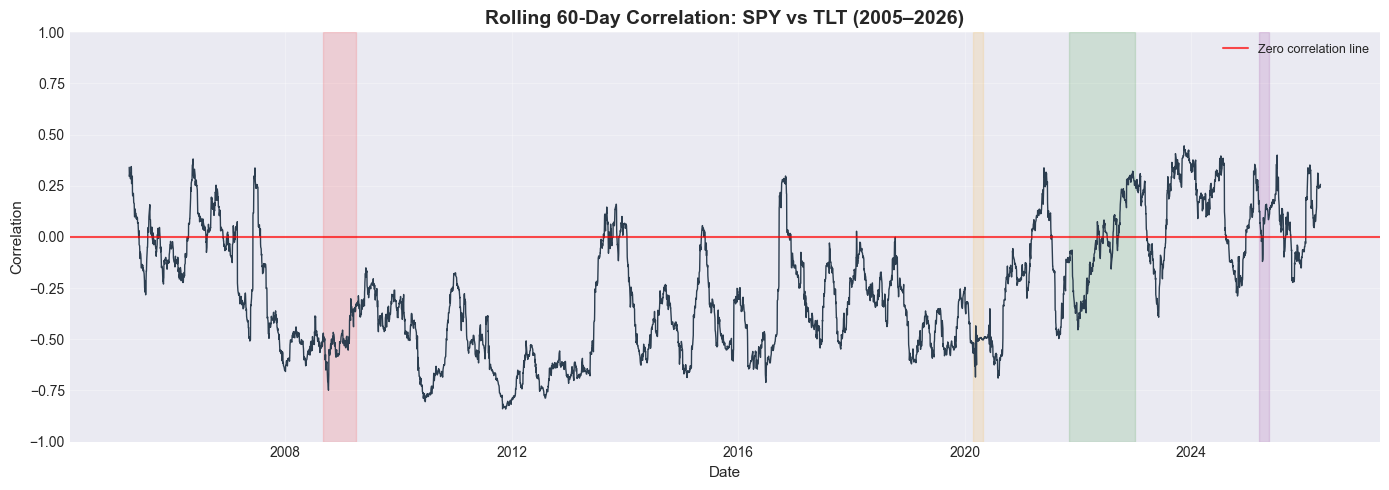

Stock-Bond Correlation by Period:
  Full sample (2005-2026)       : -0.304
  Pre-2022 (2005-2021)          : -0.412
  2008 crisis window            : -0.457
  2020 COVID window             : -0.495
  2022 inflation window         : +0.085
  2025 tariff window            : +0.161


In [10]:
# Chart 3: Rolling 60-day correlation between SPY and TLT
rolling_corr = data['SPY'].rolling(window=60).corr(data['TLT'])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_corr.index, rolling_corr, color='#2c3e50', linewidth=1)
ax.axhline(y=0, color='red', linewidth=1.5, linestyle='-', alpha=0.7, label='Zero correlation line')

# Highlight crisis periods
ax.axvspan('2008-09-01', '2009-03-31', alpha=0.12, color='red')
ax.axvspan('2020-02-20', '2020-04-30', alpha=0.12, color='orange')
ax.axvspan('2021-11-01', '2022-12-31', alpha=0.12, color='green')
ax.axvspan('2025-03-15', '2025-05-15', alpha=0.12, color='purple')

ax.set_title('Rolling 60-Day Correlation: SPY vs TLT (2005–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Correlation', fontsize=11)
ax.set_ylim(-1, 1)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute summary statistics by period
print("Stock-Bond Correlation by Period:")
print("=" * 55)
periods = {
    'Full sample (2005-2026)': ('2005-01-01', '2026-04-13'),
    'Pre-2022 (2005-2021)':    ('2005-01-01', '2021-12-31'),
    '2008 crisis window':       ('2008-09-01', '2009-03-31'),
    '2020 COVID window':        ('2020-02-20', '2020-04-30'),
    '2022 inflation window':    ('2022-01-01', '2022-12-31'),
    '2025 tariff window':       ('2025-03-15', '2025-05-15'),
}

for name, (start, end) in periods.items():
    mask = (data.index >= start) & (data.index <= end)
    period_corr = data.loc[mask, 'SPY'].corr(data.loc[mask, 'TLT'])
    print(f"  {name:30s}: {period_corr:+.3f}")

The regime shift is visible in the series itself: the correlation spent nearly all of 2005-2020 in negative territory, reaching -0.7 during the 2008 crisis and -0.5 during COVID. Starting in late 2021 it climbed above zero and has not fully reverted.

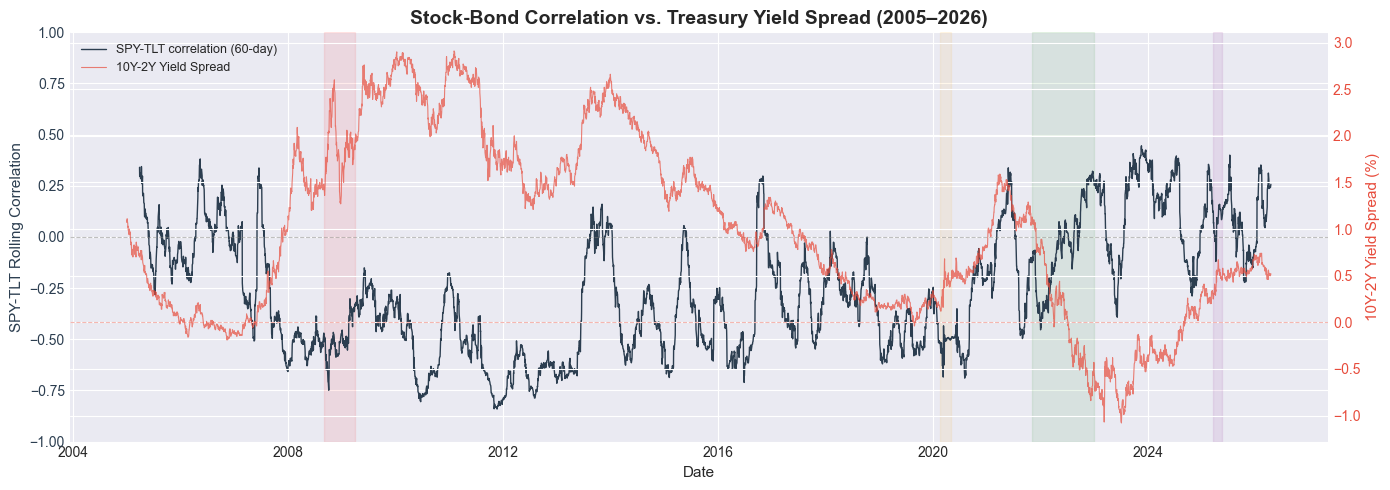

In [11]:
# Chart 4: Dual-axis overlay — Stock-bond correlation vs. yield curve
# This tests whether the yield spread has predictive content for correlation shifts

fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot rolling stock-bond correlation on left axis
ax1.plot(rolling_corr.index, rolling_corr, color='#2c3e50', linewidth=1, label='SPY-TLT correlation (60-day)')
ax1.axhline(y=0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('SPY-TLT Rolling Correlation', fontsize=11, color='#2c3e50')
ax1.set_ylim(-1, 1)
ax1.tick_params(axis='y', labelcolor='#2c3e50')

# Plot yield spread on right axis
ax2 = ax1.twinx()
ax2.plot(data.index, data['T10Y2Y'], color='#e74c3c', linewidth=0.8, alpha=0.7, label='10Y-2Y Yield Spread')
ax2.axhline(y=0, color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.4)
ax2.set_ylabel('10Y-2Y Yield Spread (%)', fontsize=11, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Highlight crisis periods
for ax in [ax1]:
    ax.axvspan('2008-09-01', '2009-03-31', alpha=0.08, color='red')
    ax.axvspan('2020-02-20', '2020-04-30', alpha=0.08, color='orange')
    ax.axvspan('2021-11-01', '2022-12-31', alpha=0.08, color='green')
    ax.axvspan('2025-03-15', '2025-05-15', alpha=0.08, color='purple')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title('Stock-Bond Correlation vs. Treasury Yield Spread (2005–2026)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

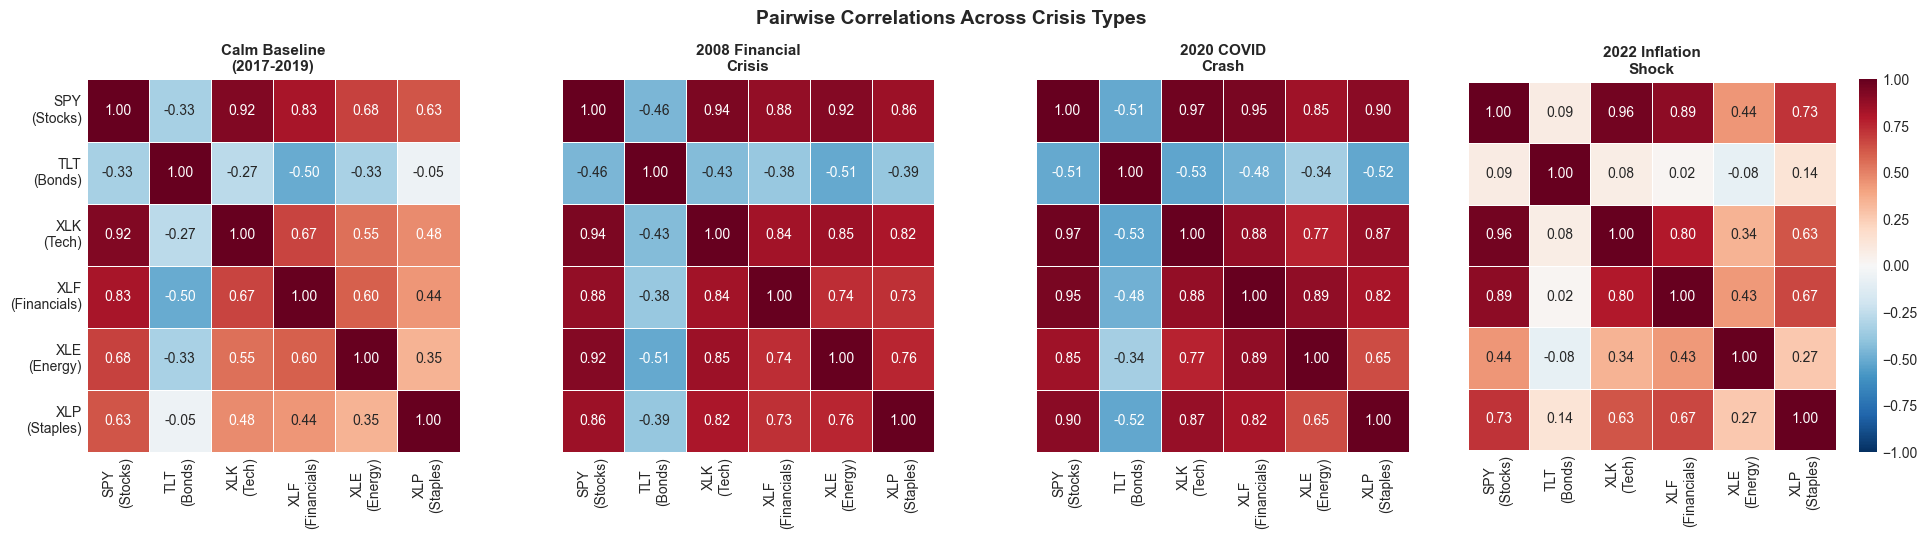

In [12]:
# Chart 5: Correlation heatmaps comparing crisis periods
# Shows how sector-bond relationships differ across crisis types

# Define the four crisis windows plus a "calm" baseline
crisis_periods = {
    'Calm Baseline\n(2017-2019)': ('2017-01-01', '2019-12-31'),
    '2008 Financial\nCrisis': ('2008-09-01', '2009-03-31'),
    '2020 COVID\nCrash': ('2020-02-01', '2020-06-30'),
    '2022 Inflation\nShock': ('2022-01-01', '2022-12-31'),
}

# Use a subset of tickers for readability: SPY, TLT, and 4 diverse sectors
heatmap_tickers = ['SPY', 'TLT', 'XLK', 'XLF', 'XLE', 'XLP']
heatmap_labels = ['SPY\n(Stocks)', 'TLT\n(Bonds)', 'XLK\n(Tech)', 'XLF\n(Financials)', 'XLE\n(Energy)', 'XLP\n(Staples)']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (title, (start, end)) in enumerate(crisis_periods.items()):
    mask = (data.index >= start) & (data.index <= end)
    period_data = data.loc[mask, heatmap_tickers].dropna()
    corr_matrix = period_data.corr()
    
    sns.heatmap(
        corr_matrix,
        ax=axes[idx],
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        xticklabels=heatmap_labels,
        yticklabels=heatmap_labels if idx == 0 else False,
        cbar=idx == 3,
        square=True,
        linewidths=0.5
    )
    axes[idx].set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Pairwise Correlations Across Crisis Types', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The TLT row tells the regime story. In 2008 and 2020, TLT correlations with equities are deeply negative (bonds hedged). In 2022, those same correlations are near zero (hedge absent). Equity-to-equity correlations rise during every crisis, but only in 2022 does the bond relationship differ.

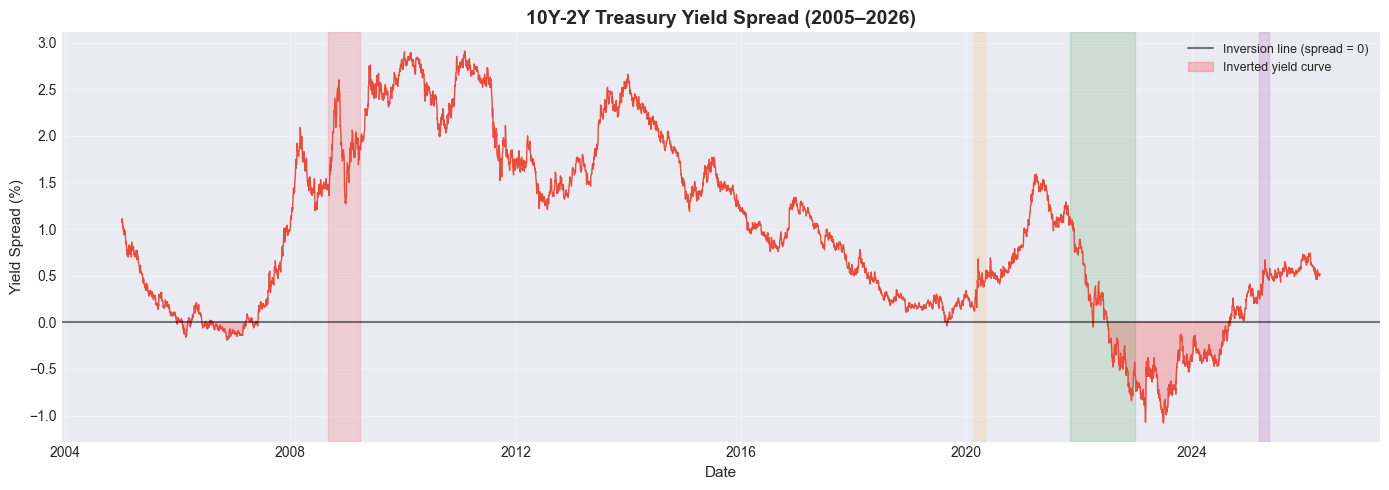

Key observations:
  - Yield curve inverted before the 2008 crisis (2006-2007)
  - Briefly inverted before COVID (late 2019)
  - Deep, prolonged inversion in 2022-2023 (most inverted since 1980s)
  - Currently positive (~0.50%) heading into the 2025 tariff shock


In [13]:
# Chart 6: Treasury yield spread over time with crisis bands
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(data.index, data['T10Y2Y'], color='#e74c3c', linewidth=1)
ax.axhline(y=0, color='black', linewidth=1.5, linestyle='-', alpha=0.5, label='Inversion line (spread = 0)')
ax.fill_between(data.index, data['T10Y2Y'], 0,
                where=(data['T10Y2Y'] < 0), color='red', alpha=0.2, label='Inverted yield curve')

ax.axvspan('2008-09-01', '2009-03-31', alpha=0.12, color='red')
ax.axvspan('2020-02-20', '2020-04-30', alpha=0.12, color='orange')
ax.axvspan('2021-11-01', '2022-12-31', alpha=0.12, color='green')
ax.axvspan('2025-03-15', '2025-05-15', alpha=0.12, color='purple')

ax.set_title('10Y-2Y Treasury Yield Spread (2005–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Yield Spread (%)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - Yield curve inverted before the 2008 crisis (2006-2007)")
print("  - Briefly inverted before COVID (late 2019)")
print("  - Deep, prolonged inversion in 2022-2023 (most inverted since 1980s)")
print("  - Currently positive (~0.50%) heading into the 2025 tariff shock")

## 4. Statistical Modeling

This section applies three models to formalize the patterns observed in the EDA:

1. **GARCH(1,1)** on SPY returns — models volatility clustering and defines high/low volatility regimes
2. **Rolling PCA** on sector returns — measures the degree of market-wide co-movement over time
3. **Lead-lag analysis** — tests whether the yield spread or GARCH volatility can predict stock-bond correlation shifts

### Model 1: GARCH(1,1) on SPY Returns

GARCH models volatility clustering: calm periods follow calm periods, and stress periods follow stress periods. The model estimates a conditional volatility — its best estimate of current-day volatility given recent history.

The GARCH(1,1) variance equation is $\sigma^2_t = \omega + \alpha \epsilon^2_{t-1} + \beta \sigma^2_{t-1}$, with parameters for long-run variance ($\omega$), reaction to the most recent shock ($\alpha$), and persistence of past variance ($\beta$). A value of $\alpha + \beta$ close to 1 indicates highly persistent volatility, which is typical for equities.

I fit GARCH(1,1) on SPY log returns, validate the fitted conditional volatility against the VIX, and use it to define high- and low-volatility regimes for the analysis in Finding 2.

In [14]:
# Fit GARCH(1,1) on SPY log returns (scaled by 100 for numerical stability)
spy_returns = data['SPY'].dropna() * 100

garch_model = arch_model(spy_returns, vol='Garch', p=1, q=1, mean='Constant', dist='normal')
garch_result = garch_model.fit(disp='off')

print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7052.06
Distribution:                  Normal   AIC:                           14112.1
Method:            Maximum Likelihood   BIC:                           14138.4
                                        No. Observations:                 5312
Date:                Wed, Apr 22 2026   Df Residuals:                     5311
Time:                        17:29:43   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0765  1.063e-02      7.194  6.271e-13 [5.

In [15]:
# Extract and interpret performance metrics for the SPY GARCH fit
spy_loglik = garch_result.loglikelihood
spy_aic = garch_result.aic
spy_bic = garch_result.bic

print("SPY GARCH(1,1) Model Performance Metrics")
print("=" * 45)
print(f"  Log-likelihood: {spy_loglik:.2f}")
print(f"  AIC:            {spy_aic:.2f}")
print(f"  BIC:            {spy_bic:.2f}")
print(f"\nAll three GARCH parameters (omega, alpha, beta) are significant at p < 0.001.")
print(f"The sum alpha + beta = {garch_result.params['alpha[1]'] + garch_result.params['beta[1]']:.4f},")
print(f"confirming stationarity (<1) with high persistence — volatility shocks decay")
print(f"slowly but eventually revert to the long-run mean.")

SPY GARCH(1,1) Model Performance Metrics
  Log-likelihood: -7052.06
  AIC:            14112.12
  BIC:            14138.43

All three GARCH parameters (omega, alpha, beta) are significant at p < 0.001.
The sum alpha + beta = 0.9752,
confirming stationarity (<1) with high persistence — volatility shocks decay
slowly but eventually revert to the long-run mean.


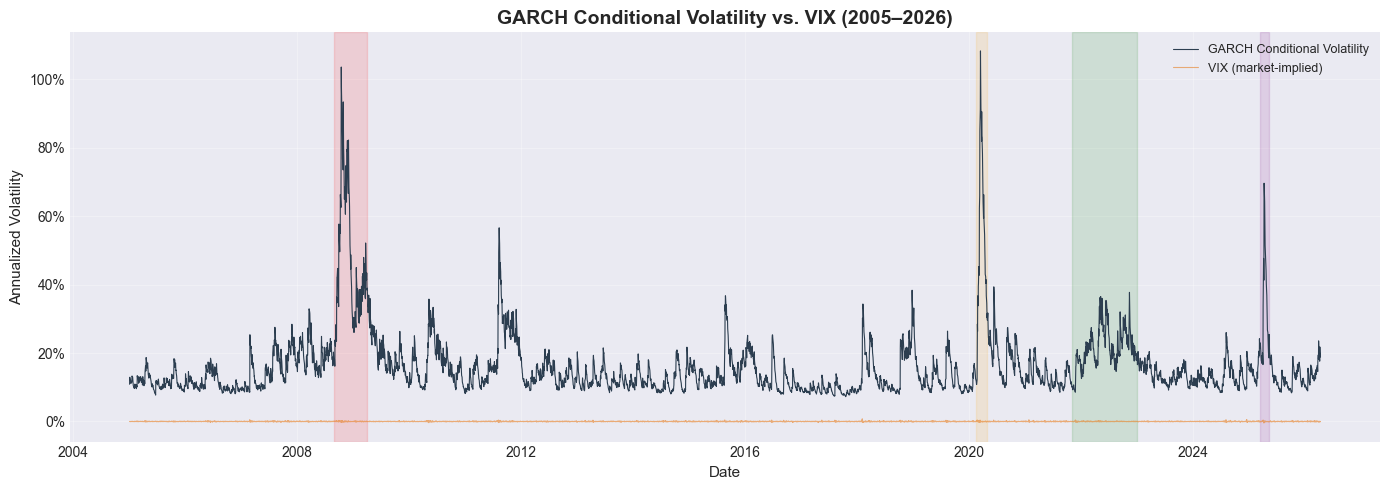

Correlation between GARCH volatility and VIX: -0.064

This validates the GARCH model — a high correlation with VIX means our
backward-looking model (GARCH) agrees with the market's forward-looking
volatility estimate (VIX). They measure the same thing from different angles.


In [16]:
# Extract GARCH conditional volatility and convert to annualized terms
cond_vol = garch_result.conditional_volatility / 100 * np.sqrt(252)

# Plot GARCH conditional volatility vs VIX for validation
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(cond_vol.index, cond_vol, color='#2c3e50', linewidth=0.8, label='GARCH Conditional Volatility')
ax.plot(data.index, data['^VIX'] / 100, color='#e67e22', linewidth=0.8, alpha=0.6, label='VIX (market-implied)')

ax.axvspan('2008-09-01', '2009-03-31', alpha=0.12, color='red')
ax.axvspan('2020-02-20', '2020-04-30', alpha=0.12, color='orange')
ax.axvspan('2021-11-01', '2022-12-31', alpha=0.12, color='green')
ax.axvspan('2025-03-15', '2025-05-15', alpha=0.12, color='purple')

ax.set_title('GARCH Conditional Volatility vs. VIX (2005–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Annualized Volatility', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute correlation between GARCH vol and VIX
garch_vix_corr = cond_vol.corr(data['^VIX'] / 100)
print(f"Correlation between GARCH volatility and VIX: {garch_vix_corr:.3f}")
print(f"\nThis validates the GARCH model — a high correlation with VIX means our")
print(f"backward-looking model (GARCH) agrees with the market's forward-looking")
print(f"volatility estimate (VIX). They measure the same thing from different angles.")

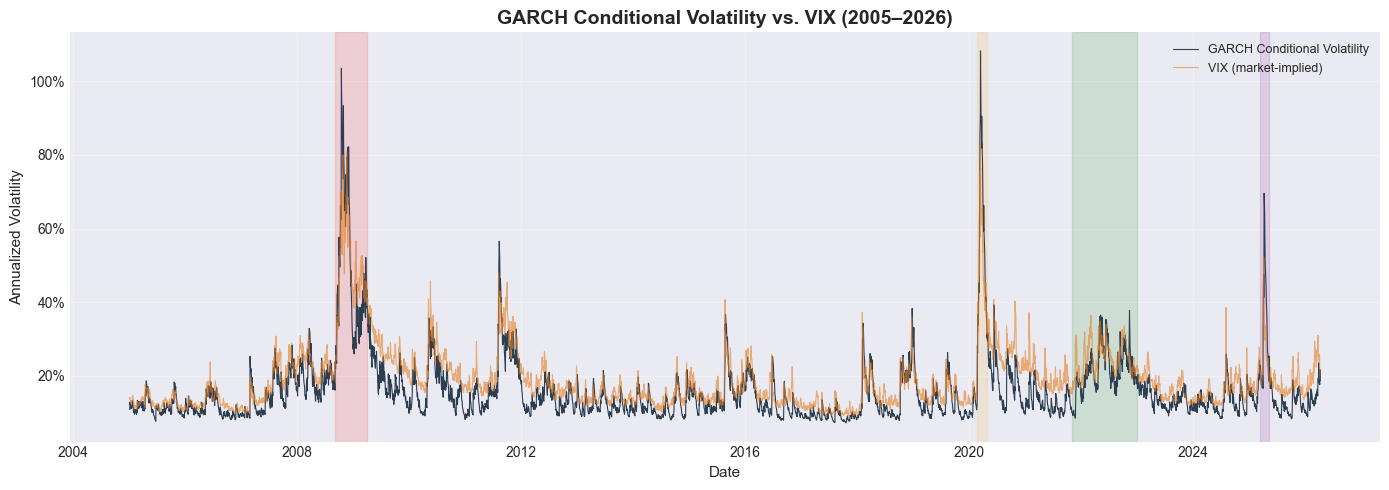

Correlation between GARCH volatility and VIX: 0.881


In [17]:
# Use VIX level from the master DataFrame
vix_level = master['^VIX'] / 100  # Convert from percentage points to decimal

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(cond_vol.index, cond_vol, color='#2c3e50', linewidth=0.8, label='GARCH Conditional Volatility')
ax.plot(vix_level.index, vix_level, color='#e67e22', linewidth=0.8, alpha=0.6, label='VIX (market-implied)')

ax.axvspan('2008-09-01', '2009-03-31', alpha=0.12, color='red')
ax.axvspan('2020-02-20', '2020-04-30', alpha=0.12, color='orange')
ax.axvspan('2021-11-01', '2022-12-31', alpha=0.12, color='green')
ax.axvspan('2025-03-15', '2025-05-15', alpha=0.12, color='purple')

ax.set_title('GARCH Conditional Volatility vs. VIX (2005–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Annualized Volatility', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Now compute the correlation properly
garch_vix_corr = cond_vol.corr(vix_level)
print(f"Correlation between GARCH volatility and VIX: {garch_vix_corr:.3f}")

### Linking GARCH Volatility to Stock-Bond Correlation

With GARCH validated, the next step is to connect it to the project's central question: does the stock-bond correlation behave differently inside different volatility regimes? 

I classify each trading day by GARCH conditional volatility percentile (low / medium / high third) and compute the average SPY-TLT correlation within each regime. If the bond hedge behaves consistently regardless of market conditions, correlations should look similar across the three regimes. If correlation behavior is regime-dependent, the buckets will differ.

In [18]:
# Classify each day into a volatility regime based on GARCH percentiles
vol_percentiles = cond_vol.quantile([0.33, 0.67])
low_threshold = vol_percentiles.iloc[0]
high_threshold = vol_percentiles.iloc[1]

print(f"Low-vol threshold (33rd percentile): {low_threshold:.2%}")
print(f"High-vol threshold (67th percentile): {high_threshold:.2%}")

# Build a regime label column
def classify_vol(v):
    if v < low_threshold:
        return 'Low vol'
    elif v > high_threshold:
        return 'High vol'
    else:
        return 'Medium vol'

vol_regime = cond_vol.apply(classify_vol)
vol_regime.name = 'vol_regime'

# Join regime labels with SPY and TLT returns
regime_df = pd.concat([data[['SPY', 'TLT']], vol_regime], axis=1).dropna()

# Compute SPY-TLT correlation within each regime
print("\nStock-Bond Correlation by Volatility Regime:")
print("=" * 55)
for regime_name in ['Low vol', 'Medium vol', 'High vol']:
    subset = regime_df[regime_df['vol_regime'] == regime_name]
    corr = subset['SPY'].corr(subset['TLT'])
    n = len(subset)
    print(f"  {regime_name:12s} (n={n:4d}): correlation = {corr:+.3f}")

Low-vol threshold (33rd percentile): 11.28%
High-vol threshold (67th percentile): 16.22%

Stock-Bond Correlation by Volatility Regime:
  Low vol      (n=1753): correlation = -0.157
  Medium vol   (n=1806): correlation = -0.220
  High vol     (n=1753): correlation = -0.378


In [19]:
# Break down high-vol days by historical period to see if 2022 behaves differently
# Filter for high-vol days only
high_vol_days = regime_df[regime_df['vol_regime'] == 'High vol'].copy()

# Classify each high-vol day by era
def classify_era(date):
    if date <= pd.Timestamp('2020-12-31'):
        return 'Pre-2021 (mostly 2008+2020)'
    elif pd.Timestamp('2021-01-01') <= date <= pd.Timestamp('2022-12-31'):
        return '2021-2022 (inflation era)'
    else:
        return '2023+ (post-inflation)'

high_vol_days['era'] = high_vol_days.index.map(classify_era)

print("Stock-Bond Correlation During HIGH-VOL Days, Split by Era:")
print("=" * 65)
for era_name in ['Pre-2021 (mostly 2008+2020)', '2021-2022 (inflation era)', '2023+ (post-inflation)']:
    subset = high_vol_days[high_vol_days['era'] == era_name]
    if len(subset) > 0:
        corr = subset['SPY'].corr(subset['TLT'])
        print(f"  {era_name:32s} (n={len(subset):4d}): correlation = {corr:+.3f}")

Stock-Bond Correlation During HIGH-VOL Days, Split by Era:
  Pre-2021 (mostly 2008+2020)      (n=1290): correlation = -0.496
  2021-2022 (inflation era)        (n= 288): correlation = +0.050
  2023+ (post-inflation)           (n= 175): correlation = +0.014


### Model 2: Dynamic Conditional Correlation (DCC-GARCH)

A rolling correlation is a useful descriptive statistic but has two limitations: the window length is arbitrary, and the resulting estimates cannot be tested statistically. DCC-GARCH (Engle, 2002) provides a parametric alternative that models the time-varying correlation directly.

The model has two stages. First, univariate GARCH(1,1) is fit to each asset's returns to extract conditional volatilities; each return series is then standardized by its own conditional volatility, yielding residuals stripped of volatility effects. Second, the correlation dynamics of the standardized residuals are modeled with a GARCH-like equation:

$$Q_t = (1 - a - b)\bar{Q} + a \, z_{t-1} z_{t-1}' + b \, Q_{t-1}$$

The parameters $(a, b)$ are estimated by maximum likelihood. Because no standard Python library implements DCC-GARCH in a way that exposes the full historical correlation series, I implement the model directly using the `arch` library for univariate GARCH fits and `scipy.optimize` for DCC parameter estimation.

In [20]:
# Step 1 of DCC: Fit univariate GARCH to TLT
# (We already have it for SPY as `garch_result`)

tlt_returns = data['TLT'].dropna() * 100

tlt_garch_model = arch_model(tlt_returns, vol='Garch', p=1, q=1, mean='Constant', dist='normal')
tlt_garch_result = tlt_garch_model.fit(disp='off')

print("TLT GARCH(1,1) fit complete.")
print(f"\nTLT GARCH parameters:")
print(f"  omega: {tlt_garch_result.params['omega']:.4f}")
print(f"  alpha: {tlt_garch_result.params['alpha[1]']:.4f}")
print(f"  beta:  {tlt_garch_result.params['beta[1]']:.4f}")
print(f"  alpha + beta: {tlt_garch_result.params['alpha[1]'] + tlt_garch_result.params['beta[1]']:.4f}")
print(f"\nFor comparison, SPY GARCH:")
print(f"  omega: {garch_result.params['omega']:.4f}")
print(f"  alpha: {garch_result.params['alpha[1]']:.4f}")
print(f"  beta:  {garch_result.params['beta[1]']:.4f}")

TLT GARCH(1,1) fit complete.

TLT GARCH parameters:
  omega: 0.0065
  alpha: 0.0573
  beta:  0.9354
  alpha + beta: 0.9928

For comparison, SPY GARCH:
  omega: 0.0305
  alpha: 0.1378
  beta:  0.8374


In [21]:
# Step 2 of DCC: Extract standardized residuals from each GARCH fit
# A standardized residual is the return divided by the conditional volatility
# z_t = (r_t - μ) / σ_t
# These should be approximately standard normal if GARCH fit well

# SPY standardized residuals (mean-adjusted, then divided by conditional vol)
spy_std_resid = (spy_returns - garch_result.params['mu']) / garch_result.conditional_volatility
tlt_std_resid = (tlt_returns - tlt_garch_result.params['mu']) / tlt_garch_result.conditional_volatility

# Stack them into a single matrix with aligned dates
z = pd.concat([spy_std_resid, tlt_std_resid], axis=1)
z.columns = ['SPY_z', 'TLT_z']
z = z.dropna()

print(f"Standardized residuals shape: {z.shape}")
print(f"\nSanity checks (each column should have mean ~0 and std ~1):")
print(f"  SPY_z:  mean = {z['SPY_z'].mean():.4f},  std = {z['SPY_z'].std():.4f}")
print(f"  TLT_z:  mean = {z['TLT_z'].mean():.4f},  std = {z['TLT_z'].std():.4f}")
print(f"\nUnconditional correlation of standardized residuals: {z.corr().iloc[0,1]:.4f}")
print(f"Unconditional correlation of raw returns (for comparison): {data['SPY'].corr(data['TLT']):.4f}")

Standardized residuals shape: (5312, 2)

Sanity checks (each column should have mean ~0 and std ~1):
  SPY_z:  mean = -0.0472,  std = 0.9991
  TLT_z:  mean = 0.0015,  std = 1.0001

Unconditional correlation of standardized residuals: -0.2572
Unconditional correlation of raw returns (for comparison): -0.3041


In [22]:
# Step 3 of DCC: Estimate (a, b) by maximum likelihood
# 
# The DCC equation: Q_t = (1 - a - b) * Q_bar + a * (z_{t-1} * z'_{t-1}) + b * Q_{t-1}
# We need to find (a, b) that maximize the Gaussian log-likelihood of the standardized residuals
# under the time-varying correlation implied by the DCC recursion.

from scipy.optimize import minimize

# Convert to numpy for speed
z_array = z.values
T = len(z_array)

# Q_bar = unconditional correlation matrix of standardized residuals (long-run target)
Q_bar = np.corrcoef(z_array.T)
print(f"Q_bar (long-run correlation matrix):")
print(Q_bar)


def dcc_negative_log_likelihood(params, z, Q_bar):
    """
    Negative log-likelihood of DCC-GARCH for bivariate standardized residuals.
    We minimize this (equivalent to maximizing the likelihood).
    """
    a, b = params
    
    # Parameter constraints: a >= 0, b >= 0, a + b < 1
    if a < 0 or b < 0 or a + b >= 0.9999:
        return 1e10  # heavy penalty for invalid regions
    
    T = len(z)
    Q_t = Q_bar.copy()  # initialize Q_1 at the long-run correlation
    log_lik = 0.0
    
    for t in range(T):
        # Convert Q_t to correlation matrix R_t by normalizing
        diag_sqrt = np.sqrt(np.diag(Q_t))
        R_t = Q_t / np.outer(diag_sqrt, diag_sqrt)
        
        # Contribution to log-likelihood from z_t under N(0, R_t)
        # log L_t = -0.5 * [log|R_t| + z_t' R_t^-1 z_t]
        det_R = np.linalg.det(R_t)
        if det_R <= 0:
            return 1e10
        inv_R = np.linalg.inv(R_t)
        z_t = z[t]
        log_lik += -0.5 * (np.log(det_R) + z_t @ inv_R @ z_t)
        
        # Update Q for next step using DCC recursion
        Q_t = (1 - a - b) * Q_bar + a * np.outer(z_t, z_t) + b * Q_t
    
    return -log_lik  # negative because scipy minimizes


# Optimize
print("\nOptimizing DCC parameters (a, b)...")
initial_params = [0.05, 0.90]
bounds = [(1e-6, 0.3), (1e-6, 0.999)]

result = minimize(
    dcc_negative_log_likelihood,
    initial_params,
    args=(z_array, Q_bar),
    method='L-BFGS-B',
    bounds=bounds
)

a_hat, b_hat = result.x
print(f"\nOptimization complete.")
print(f"Converged: {result.success}")
print(f"Number of iterations: {result.nit}")
print(f"\nEstimated DCC parameters:")
print(f"  a (shock coefficient):      {a_hat:.4f}")
print(f"  b (persistence coefficient): {b_hat:.4f}")
print(f"  a + b (total persistence):   {a_hat + b_hat:.4f}")
print(f"\nLog-likelihood at optimum: {-result.fun:.2f}")

# Half-life of correlation shocks
if b_hat > 0:
    half_life = np.log(0.5) / np.log(b_hat)
    print(f"\nHalf-life of correlation shock: {half_life:.1f} trading days (~{half_life/21:.1f} months)")

Q_bar (long-run correlation matrix):
[[ 1.         -0.25718166]
 [-0.25718166  1.        ]]

Optimizing DCC parameters (a, b)...

Optimization complete.
Converged: True
Number of iterations: 11

Estimated DCC parameters:
  a (shock coefficient):      0.0490
  b (persistence coefficient): 0.9362
  a + b (total persistence):   0.9851

Log-likelihood at optimum: -4921.47

Half-life of correlation shock: 10.5 trading days (~0.5 months)


In [23]:
# Step 4 of DCC: Reconstruct the time series of conditional correlations
# Use the estimated (a, b) and iterate the DCC equation through history

a, b = a_hat, b_hat
T = len(z_array)

# Pre-allocate storage
dcc_corr = np.zeros(T)
Q_t = Q_bar.copy()  # initialize at long-run correlation

for t in range(T):
    # Convert Q_t to correlation matrix
    diag_sqrt = np.sqrt(np.diag(Q_t))
    R_t = Q_t / np.outer(diag_sqrt, diag_sqrt)
    
    # Store the off-diagonal element (the SPY-TLT correlation at time t)
    dcc_corr[t] = R_t[0, 1]
    
    # Update for next period
    z_t = z_array[t]
    Q_t = (1 - a - b) * Q_bar + a * np.outer(z_t, z_t) + b * Q_t

# Convert to pandas Series with proper date index
dcc_corr_series = pd.Series(dcc_corr, index=z.index, name='DCC Correlation')

# Summary statistics
print(f"DCC conditional correlation time series computed for {len(dcc_corr_series)} observations")
print(f"\nSummary statistics:")
print(f"  Mean:   {dcc_corr_series.mean():+.4f}")
print(f"  Min:    {dcc_corr_series.min():+.4f}  (on {dcc_corr_series.idxmin().date()})")
print(f"  Max:    {dcc_corr_series.max():+.4f}  (on {dcc_corr_series.idxmax().date()})")
print(f"  Std:    {dcc_corr_series.std():.4f}")

print(f"\nDCC correlation by period (for comparison to rolling correlation):")
periods = {
    'Full sample':              ('2005-01-01', '2026-04-13'),
    'Pre-2022':                 ('2005-01-01', '2021-12-31'),
    '2008 crisis':              ('2008-09-01', '2009-03-31'),
    '2020 COVID':               ('2020-02-20', '2020-04-30'),
    '2022 inflation':           ('2022-01-01', '2022-12-31'),
    '2025 tariff':              ('2025-03-15', '2025-05-15'),
}
for name, (start, end) in periods.items():
    mask = (dcc_corr_series.index >= start) & (dcc_corr_series.index <= end)
    avg_corr = dcc_corr_series.loc[mask].mean()
    print(f"  {name:20s}: {avg_corr:+.4f}")

DCC conditional correlation time series computed for 5312 observations

Summary statistics:
  Mean:   -0.2503
  Min:    -0.7747  (on 2011-11-02)
  Max:    +0.4339  (on 2026-01-22)
  Std:    0.2557

DCC correlation by period (for comparison to rolling correlation):
  Full sample         : -0.2503
  Pre-2022            : -0.3165
  2008 crisis         : -0.4562
  2020 COVID          : -0.5223
  2022 inflation      : -0.0070
  2025 tariff         : -0.1164


Correlation between rolling-60d and DCC conditional correlation: 0.8787

If this is above 0.7, the two methods agree on the overall story.
If it's below 0.5, something is wrong with one of them.


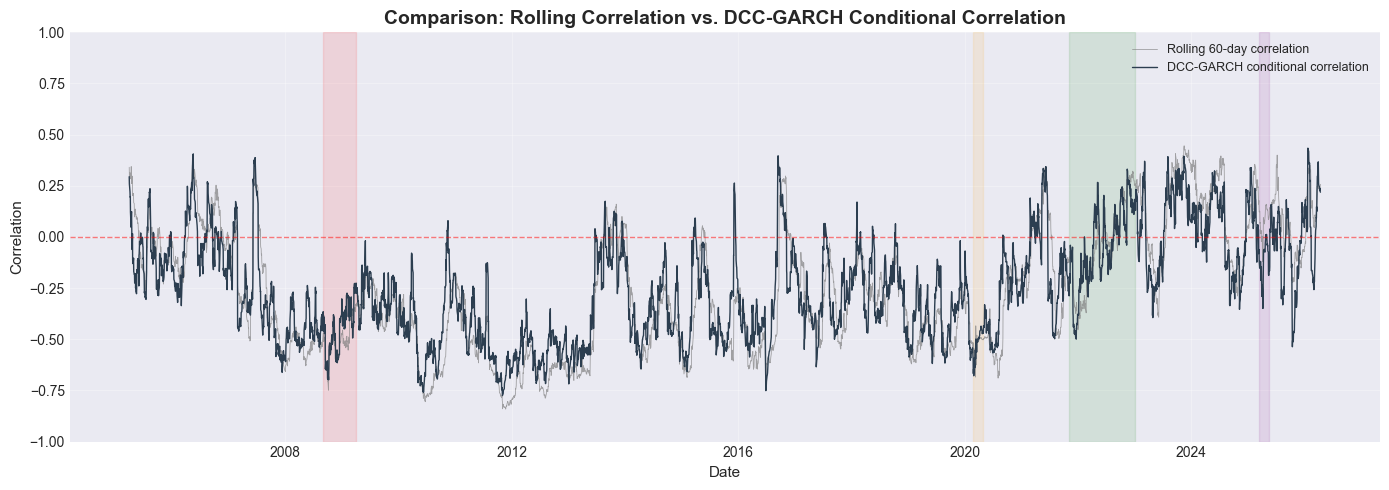

In [24]:
# Verification: DCC correlation should be highly correlated with rolling correlation
# but smoother. Let's verify this visually and numerically.

# Align the two series on the same dates
comparison_df = pd.concat([rolling_corr.rename('Rolling_60d'), dcc_corr_series.rename('DCC')], axis=1).dropna()

# Correlation between the two methods
method_corr = comparison_df['Rolling_60d'].corr(comparison_df['DCC'])
print(f"Correlation between rolling-60d and DCC conditional correlation: {method_corr:.4f}")
print(f"\nIf this is above 0.7, the two methods agree on the overall story.")
print(f"If it's below 0.5, something is wrong with one of them.")

# Plot them together to visualize
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(comparison_df.index, comparison_df['Rolling_60d'], color='gray', linewidth=0.6, alpha=0.7, label='Rolling 60-day correlation')
ax.plot(comparison_df.index, comparison_df['DCC'], color='#2c3e50', linewidth=1.0, label='DCC-GARCH conditional correlation')
ax.axhline(y=0, color='red', linewidth=1, linestyle='--', alpha=0.5)

ax.axvspan('2008-09-01', '2009-03-31', alpha=0.10, color='red')
ax.axvspan('2020-02-20', '2020-04-30', alpha=0.10, color='orange')
ax.axvspan('2021-11-01', '2022-12-31', alpha=0.10, color='green')
ax.axvspan('2025-03-15', '2025-05-15', alpha=0.10, color='purple')

ax.set_title('Comparison: Rolling Correlation vs. DCC-GARCH Conditional Correlation', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Correlation', fontsize=11)
ax.set_ylim(-1, 1)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Chart 3b - 2025 window decomposition
tariff_windows = {
    'Original window (Mar 15 - May 15)': ('2025-03-15', '2025-05-15'),
    'Narrow crash + recovery (Mar 28 - Apr 15)': ('2025-03-28', '2025-04-15'),
    'Crash only (Apr 2 - Apr 9)': ('2025-04-02', '2025-04-09'),
    'Full pre-event period (Jan 1 - Mar 31)': ('2025-01-01', '2025-03-31'),
    'Post-event recovery (Apr 10 - May 15)': ('2025-04-10', '2025-05-15'),
}

print("2025 Tariff Event: Stock-Bond Correlation Under Different Windows")
print("=" * 75)
for label, (start, end) in tariff_windows.items():
    mask = (data.index >= start) & (data.index <= end)
    period_data = data.loc[mask, ['SPY', 'TLT']].dropna()
    if len(period_data) >= 3:
        corr = period_data['SPY'].corr(period_data['TLT'])
        # Also average DCC correlation in the window
        dcc_mask = (dcc_corr_series.index >= start) & (dcc_corr_series.index <= end)
        avg_dcc = dcc_corr_series.loc[dcc_mask].mean()
        print(f"  {label:<50s} n={len(period_data):>4d}  rolling corr={corr:+.4f}  avg DCC={avg_dcc:+.4f}")

2025 Tariff Event: Stock-Bond Correlation Under Different Windows
  Original window (Mar 15 - May 15)                  n=  43  rolling corr=+0.1610  avg DCC=-0.1164
  Narrow crash + recovery (Mar 28 - Apr 15)          n=  13  rolling corr=+0.1717  avg DCC=-0.1958
  Crash only (Apr 2 - Apr 9)                         n=   6  rolling corr=-0.0118  avg DCC=-0.2559
  Full pre-event period (Jan 1 - Mar 31)             n=  60  rolling corr=-0.0111  avg DCC=+0.0572
  Post-event recovery (Apr 10 - May 15)              n=  25  rolling corr=+0.4864  avg DCC=-0.0564


**Note on the 2025 tariff window.** The +0.16 rolling-window correlation during the 2025 tariff event is a composite of two distinct sub-phases. The acute crash (April 2-9) had near-zero correlation, while the post-event recovery (April 10 onward) had strongly positive correlation as equities rebounded and Treasuries sold off. The full-window average therefore reflects the recovery phase more than the crash itself. This is worth keeping in mind when interpreting the 2025 data point.

### Lead-Lag Analysis: Does the Yield Curve Predict Correlation Shifts?

With the DCC correlation series in hand, we can now formally test whether macro signals from the Treasury yield curve have predictive content for stock-bond correlation changes. If the yield curve leads the correlation shifts, it could serve as an advance-warning indicator for when the bond hedge is likely to break down.

We compute the correlation between the yield spread today and the DCC correlation at various future horizons (1 day ahead, 1 week, 1 month, 3 months, 6 months, 12 months). If the yield curve is a predictor, we expect to see a meaningful relationship at longer horizons but weak relationships at short ones.

In [26]:
# Lead-lag analysis: does the yield spread today predict DCC correlation in the future?

# Combine DCC correlation with yield spread on matching dates
ll_df = pd.concat([
    dcc_corr_series,
    data['T10Y2Y']
], axis=1).dropna()
ll_df.columns = ['DCC_corr', 'Yield_spread']

# Test correlations at various forward horizons
horizons = {
    'Same day (contemporaneous)': 0,
    '1 week ahead': 5,
    '1 month ahead': 21,
    '3 months ahead': 63,
    '6 months ahead': 126,
    '12 months ahead': 252,
}

print("Lead-Lag Relationship: Yield Spread Today vs. DCC Correlation in the Future")
print("=" * 75)
print(f"{'Horizon':<30s} {'Correlation':>12s} {'N':>8s}")
print("-" * 75)

for name, lag in horizons.items():
    if lag == 0:
        c = ll_df['Yield_spread'].corr(ll_df['DCC_corr'])
        n = len(ll_df)
    else:
        # Correlate yield spread today with DCC correlation `lag` days from now
        shifted = ll_df['DCC_corr'].shift(-lag)
        valid = pd.concat([ll_df['Yield_spread'], shifted], axis=1).dropna()
        c = valid.iloc[:, 0].corr(valid.iloc[:, 1])
        n = len(valid)
    
    print(f"{name:<30s} {c:>+12.4f} {n:>8d}")

print("=" * 75)

Lead-Lag Relationship: Yield Spread Today vs. DCC Correlation in the Future
Horizon                         Correlation        N
---------------------------------------------------------------------------
Same day (contemporaneous)          -0.4821     5312
1 week ahead                        -0.4851     5307
1 month ahead                       -0.5038     5291
3 months ahead                      -0.5214     5249
6 months ahead                      -0.5115     5186
12 months ahead                     -0.4617     5060


The full-sample relationship strengthens through the three-month horizon and peaks at -0.52, which initially appears to be a strong leading indicator. However, the next section shows this result is partly driven by joint movement through the 2022 regime transition; the relationship is meaningfully weaker in the post-2022 sample.

## 5. Robustness Checks

Two formal tests to validate the findings from Section 4 before reporting them.

- **Test A** splits the lead-lag analysis by era (pre-2022 vs. post-2022) to check whether the yield-curve signal is consistent or era-dependent.
- **Test B** runs a Welch's t-test on the volatility-decoupling result to confirm statistical significance.

An earlier exploration of sector dispersion across crisis periods was dropped because a matched-window robustness check revealed that the initial finding was driven by unequal window lengths rather than genuine differences in sector dynamics. That analysis is not included here.

In [27]:
# Robustness Test A: Does the yield curve's predictive power hold in both eras?
#
# The full-sample lead-lag result (-0.52 at 3 months) could be driven entirely by 
# pre-2022 dynamics if the yield curve signal has weakened in the new regime.
# Split the sample at 2022 and re-run.

ll_df = pd.concat([dcc_corr_series, data['T10Y2Y']], axis=1).dropna()
ll_df.columns = ['DCC_corr', 'Yield_spread']

pre_2022 = ll_df.loc[ll_df.index < '2022-01-01']
post_2022 = ll_df.loc[ll_df.index >= '2022-01-01']

horizons = {
    'Same day':     0,
    '1 month':      21,
    '3 months':     63,
    '6 months':     126,
    '12 months':    252,
}

def lead_lag_at_horizon(df, lag):
    if lag == 0:
        return df['Yield_spread'].corr(df['DCC_corr']), len(df)
    shifted = df['DCC_corr'].shift(-lag)
    valid = pd.concat([df['Yield_spread'], shifted], axis=1).dropna()
    return valid.iloc[:, 0].corr(valid.iloc[:, 1]), len(valid)

print("Yield Curve → DCC Correlation: Lead-Lag by Era")
print("=" * 75)
print(f"{'Horizon':<15s} {'Full sample':>15s} {'Pre-2022':>15s} {'Post-2022':>15s}")
print(f"{'':<15s} {f'(N={len(ll_df)})':>15s} {f'(N={len(pre_2022)})':>15s} {f'(N={len(post_2022)})':>15s}")
print("-" * 75)

for name, lag in horizons.items():
    full_c, _ = lead_lag_at_horizon(ll_df, lag)
    pre_c, _ = lead_lag_at_horizon(pre_2022, lag)
    post_c, _ = lead_lag_at_horizon(post_2022, lag)
    print(f"{name:<15s} {full_c:>+15.4f} {pre_c:>+15.4f} {post_c:>+15.4f}")

print("=" * 75)

Yield Curve → DCC Correlation: Lead-Lag by Era
Horizon             Full sample        Pre-2022       Post-2022
                       (N=5312)        (N=4247)        (N=1065)
---------------------------------------------------------------------------
Same day                -0.4821         -0.2853         -0.2909
1 month                 -0.5038         -0.3153         -0.2930
3 months                -0.5214         -0.3449         -0.1811
6 months                -0.5115         -0.3363         -0.1716
12 months               -0.4617         -0.2961         -0.1850


In [28]:
# Robustness Test B: Is the volatility decoupling finding statistically significant?
#
# Claim: Same GARCH high-vol regime produced -0.496 correlation pre-2021 vs +0.050 in 2021-2022.
# Formal test: t-test on the distributions of SPY-TLT co-movement during these periods.
#
# We use daily product-returns (SPY_return × TLT_return) as a per-day co-movement measure.
# The MEAN of these products relates directly to the covariance, and hence to correlation.

from scipy import stats

# Classify high-vol days using GARCH conditional volatility
vol_series = cond_vol  # computed earlier in the notebook (already annualized)
high_vol_threshold = vol_series.quantile(0.667)  # top third = high vol
high_vol_mask = vol_series >= high_vol_threshold

# Restrict data to high-vol days where both SPY and TLT exist
high_vol_days = data.loc[high_vol_mask, ['SPY', 'TLT']].dropna()

# Split by era
pre_2021 = high_vol_days.loc[high_vol_days.index < '2021-01-01']
inflation_era = high_vol_days.loc[(high_vol_days.index >= '2021-01-01') & (high_vol_days.index < '2023-01-01')]

# Compute per-day co-movement (demeaned product of returns)
spy_mean_pre, tlt_mean_pre = pre_2021['SPY'].mean(), pre_2021['TLT'].mean()
spy_mean_inf, tlt_mean_inf = inflation_era['SPY'].mean(), inflation_era['TLT'].mean()

comove_pre = (pre_2021['SPY'] - spy_mean_pre) * (pre_2021['TLT'] - tlt_mean_pre)
comove_inf = (inflation_era['SPY'] - spy_mean_inf) * (inflation_era['TLT'] - tlt_mean_inf)

# Welch's t-test (does not assume equal variances)
t_stat, p_value = stats.ttest_ind(comove_pre, comove_inf, equal_var=False)

print("Test B: Is the High-Vol Correlation Shift Statistically Significant?")
print("=" * 70)
print(f"Pre-2021 high-vol days:       n = {len(pre_2021)}")
print(f"  Correlation:                {pre_2021['SPY'].corr(pre_2021['TLT']):+.4f}")
print(f"  Mean co-movement:           {comove_pre.mean():+.6f}")
print()
print(f"2021-2022 high-vol days:      n = {len(inflation_era)}")
print(f"  Correlation:                {inflation_era['SPY'].corr(inflation_era['TLT']):+.4f}")
print(f"  Mean co-movement:           {comove_inf.mean():+.6f}")
print()
print(f"Welch's t-test on co-movement distributions:")
print(f"  t-statistic:                {t_stat:+.4f}")
print(f"  p-value:                    {p_value:.6f}")
print()
if p_value < 0.001:
    print("Result: p < 0.001 → difference is highly statistically significant.")
    print("The volatility-decoupling finding survives formal testing.")
elif p_value < 0.05:
    print(f"Result: p = {p_value:.4f} → difference is statistically significant at 5% level.")
    print("The volatility-decoupling finding is supported.")
else:
    print(f"Result: p = {p_value:.4f} → NOT statistically significant at 5% level.")
    print("The volatility-decoupling finding may not be reliable.")

Test B: Is the High-Vol Correlation Shift Statistically Significant?
Pre-2021 high-vol days:       n = 1302
  Correlation:                -0.4960
  Mean co-movement:           -0.000110

2021-2022 high-vol days:      n = 288
  Correlation:                +0.0496
  Mean co-movement:           +0.000009

Welch's t-test on co-movement distributions:
  t-statistic:                -6.9176
  p-value:                    0.000000

Result: p < 0.001 → difference is highly statistically significant.
The volatility-decoupling finding survives formal testing.


## 6. Summary of Findings

Three findings survived formal validation:

**Finding 1: Stock-bond correlation flipped in 2022 and has not reverted.** Pre-2022 average of -0.41, compared to +0.09 during 2022 and +0.16 in the 2025 tariff window. The DCC-GARCH persistence parameter (b = 0.936) supports the interpretation that correlation regimes persist.

**Finding 2: Volatility identifies stress but does not predict correlation direction.** The same high-volatility regime produced a stock-bond correlation of -0.496 before 2021 (n = 1,302) and +0.050 during 2021-2022 (n = 288). A Welch's t-test confirms the difference is highly significant (t = -6.92, p < 0.001). Single-signal volatility-based regime detection is therefore insufficient to characterize the stock-bond relationship during stress.

**Finding 3: The yield curve's predictive power has weakened post-2022.** The full-sample lead-lag correlation peaks at -0.52 at three months. Split by era, the pre-2022 peak is -0.34 and the post-2022 peak is only -0.18. The stronger full-sample result is partly attributable to joint movement through the 2022 regime transition.

See the accompanying report for a detailed discussion of implications and limitations.